In [149]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
#from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

Aca importamos un dataset que armamos anteriormente en otro otebook. Vamos a hacer una prediccion de la estacion de destino de la bicicleta para la estación de origen constitución.

Acá hicimos anteriormente transformaciones sobre la fecha, obteniendo diferentes columnas de dia, mes año. Además, obtuvimos un dataset de temperatura, precipitaciones y viento, para generar un posible indice que nos mejore la predicción.

In [150]:
"year_key", "month_of_year", "day_of_month" , "iso_day_of_week", "estacion_origen", "estacion_destino", "grupo_edad", "tavg", "prcp", "wspd"

('year_key',
 'month_of_year',
 'day_of_month',
 'iso_day_of_week',
 'estacion_origen',
 'estacion_destino',
 'grupo_edad',
 'tavg',
 'prcp',
 'wspd')

In [151]:
df = pd.read_parquet("dataset_resumido2.parquet")
df = df[ df["estacion_origen"] == '236 - UBA SOCIALES']
df["hora"] = df["fecha_origen_recorrido"].dt.hour
df = df.drop(columns=["estacion_origen", "year_key","fecha_origen_recorrido", "fecha_destino_recorrido", "date_key", "date", "first_day_of_week", "last_day_of_week",
                      "first_day_of_month", "last_day_of_month", "first_day_of_quarter", "last_day_of_quarter", "first_day_of_year", "last_day_of_year"])
#df['fecha_origen_recorrido'] = pd.to_datetime(df['fecha_origen_recorrido']).astype('datetime64[s]')
#df['fecha_destino_recorrido'] = pd.to_datetime(df['fecha_destino_recorrido']).astype('datetime64[s]')
#df['date_key'] = pd.to_datetime(df['date_key']).astype('datetime64[s]')
#df['date'] = pd.to_datetime(df['date']).astype('datetime64[s]')

In [152]:
df.columns

Index(['duracion_estim_seg', 'modelo_bicicleta', 'estacion_destino',
       'genero_usuario', 'edad_usuario', 'grupo_edad', 'day_of_year',
       'week_key', 'week_of_year', 'day_of_week', 'iso_day_of_week',
       'day_name', 'month_key', 'month_of_year', 'day_of_month',
       'month_name_short', 'month_name', 'quarter_key', 'quarter_of_year',
       'day_of_quarter', 'quarter_desc_short', 'quarter_desc',
       'ordinal_weekday_of_month', 'tavg', 'prcp', 'wspd', 'hora'],
      dtype='object')

para hacer el analisis vamos a hacerlo sobre la estación de la uba de sociales

In [153]:
df

,duracion_estim_seg,modelo_bicicleta,estacion_destino,genero_usuario,edad_usuario,grupo_edad,day_of_year,week_key,week_of_year,day_of_week,...,quarter_key,quarter_of_year,day_of_quarter,quarter_desc_short,quarter_desc,ordinal_weekday_of_month,tavg,prcp,wspd,hora
622,832,FIT,131- HOSPITAL DE CLÍNICAS,MALE,31,26-35,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
1721,926,FIT,064 - RIOBAMBA,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,13
1736,1736,FIT,286 - FILOSOFIA Y LETRAS,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
1948,816,ICONIC,041 - PARQUE PATRICIOS II,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,12
2450,21,FIT,236 - UBA SOCIALES,MALE,31,26-35,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495632,490,ICONIC,073 - Ruy Díaz de Guzmán,None,<NA>,None,299,202443,43,5,...,20244,4,25,Q4,Quarter 4,4,22.6,3.3,6.7,15
3500105,683,ICONIC,152 - JULIETA LANTERI,MALE,33,26-35,302,202444,44,1,...,20244,4,28,Q4,Quarter 4,4,24.4,0.0,8.2,8
3500462,821,FIT,179 - CASA SAN,MALE,19,19-25,300,202443,43,6,...,20244,4,26,Q4,Quarter 4,4,16.9,0.0,4.7,13
3500495,385,FIT,008 - Congreso,MALE,62,56-65,300,202443,43,6,...,20244,4,26,Q4,Quarter 4,4,16.9,0.0,4.7,19


Para analizar desbalanceo de la variable de salida, vamos a ver la cantidad de salida de las 30 estaciones de destino mas grandes

In [154]:
# Get the top 20 categories by count
top_30 = df['estacion_destino'].value_counts().nlargest(30).index

# Filter the DataFrame to only include these top 20 categories
df_top30 = df[df['estacion_destino'].isin(top_30)]

<Axes: xlabel='percent', ylabel='estacion_destino'>

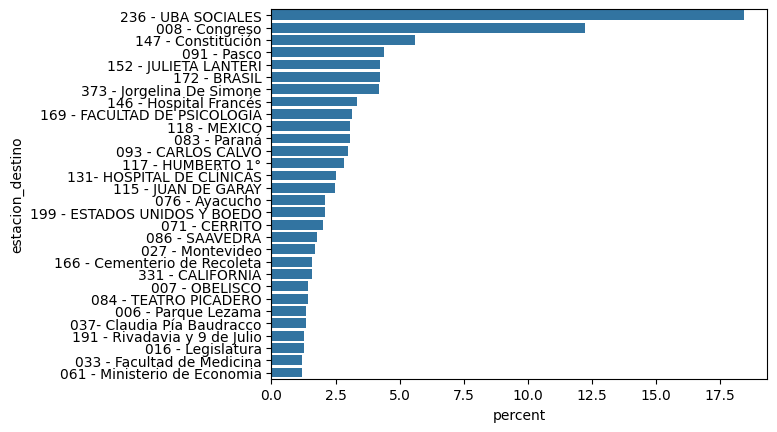

In [155]:
sns.countplot(df_top30, y="estacion_destino", order=top_30, stat='percent')

Podemos ver como en general las clases presentan una distribucion medianamente uniforme descendente, salvo por dos casos atipicos: la misma estación de uba sociales, y la estación de congreso. Vamos a ver metodologías para corregir estos desbalanceos. Consideramos que para este caso, puede existir un desbalance natural de la información, que no necesariamente es malo, ya que muestra la mayor frecuencia de utilización del transporte. Como criterio, vamos a retirar la clase mayoritaria, debido a que a fines analiticos, no podemos obtener mucha información de un viaje que salió y llegó a la misma estación.

In [156]:
df = df[df['estacion_destino']!= '236 - UBA SOCIALES']

<Axes: xlabel='percent', ylabel='estacion_destino'>

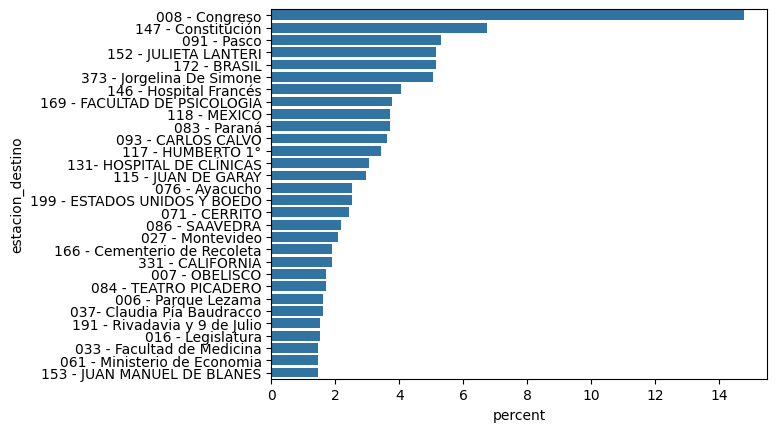

In [157]:
# Get the top 20 categories by count
top_30 = df['estacion_destino'].value_counts().nlargest(30).index

# Filter the DataFrame to only include these top 20 categories
df_top30 = df[df['estacion_destino'].isin(top_30)]
sns.countplot(df_top30, y="estacion_destino", order=top_30, stat='percent')


In [158]:
df

,duracion_estim_seg,modelo_bicicleta,estacion_destino,genero_usuario,edad_usuario,grupo_edad,day_of_year,week_key,week_of_year,day_of_week,...,quarter_key,quarter_of_year,day_of_quarter,quarter_desc_short,quarter_desc,ordinal_weekday_of_month,tavg,prcp,wspd,hora
622,832,FIT,131- HOSPITAL DE CLÍNICAS,MALE,31,26-35,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
1721,926,FIT,064 - RIOBAMBA,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,13
1736,1736,FIT,286 - FILOSOFIA Y LETRAS,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,17
1948,816,ICONIC,041 - PARQUE PATRICIOS II,None,<NA>,None,292,202442,42,5,...,20244,4,18,Q4,Quarter 4,3,21.1,0.0,8.9,12
2536,592,ICONIC,084 - TEATRO PICADERO,MALE,29,26-35,291,202442,42,4,...,20244,4,17,Q4,Quarter 4,3,26.6,0.5,7.1,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495632,490,ICONIC,073 - Ruy Díaz de Guzmán,None,<NA>,None,299,202443,43,5,...,20244,4,25,Q4,Quarter 4,4,22.6,3.3,6.7,15
3500105,683,ICONIC,152 - JULIETA LANTERI,MALE,33,26-35,302,202444,44,1,...,20244,4,28,Q4,Quarter 4,4,24.4,0.0,8.2,8
3500462,821,FIT,179 - CASA SAN,MALE,19,19-25,300,202443,43,6,...,20244,4,26,Q4,Quarter 4,4,16.9,0.0,4.7,13
3500495,385,FIT,008 - Congreso,MALE,62,56-65,300,202443,43,6,...,20244,4,26,Q4,Quarter 4,4,16.9,0.0,4.7,19


Otra metodología que puede llegarse a utilizar en este caso es la de underfitting de la categoría mayoritaria: retirar muestras de la estación de congreso:

In [159]:
X = df.drop(columns="estacion_destino").copy()
y = df["estacion_destino"].copy()

Index(['estacion_destino'], dtype='object')


<Axes: xlabel='percent', ylabel='estacion_destino'>

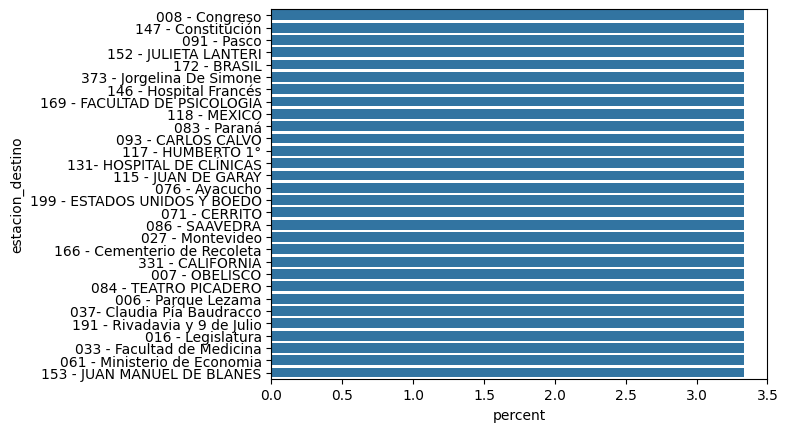

In [160]:
# Undersampling
undersample = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = undersample.fit_resample(X, y)

# Get the top 20 categories by count
y_train_us = y_train_us.to_frame()
print(y_train_us.columns)

# Filter the DataFrame to only include these top 20 categories
y_train_us_top30 = y_train_us[y_train_us['estacion_destino'].isin(top_30)]
sns.countplot(y_train_us_top30, y="estacion_destino", order=top_30, stat='percent')

In [161]:
X_train_us

,duracion_estim_seg,modelo_bicicleta,genero_usuario,edad_usuario,grupo_edad,day_of_year,week_key,week_of_year,day_of_week,iso_day_of_week,...,quarter_key,quarter_of_year,day_of_quarter,quarter_desc_short,quarter_desc,ordinal_weekday_of_month,tavg,prcp,wspd,hora
109652,1229,FIT,None,<NA>,None,352,202451,51,2,2,...,20244,4,78,Q4,Quarter 4,3,23.3,9.9,9.3,18
2430537,965,ICONIC,None,<NA>,None,285,202441,41,5,5,...,20244,4,11,Q4,Quarter 4,2,22.3,0.0,6.6,21
2102863,497,ICONIC,None,<NA>,None,306,202444,44,5,5,...,20244,4,32,Q4,Quarter 4,1,25.9,0.0,11.7,16
332267,715,ICONIC,FEMALE,28,26-35,341,202449,49,5,5,...,20244,4,67,Q4,Quarter 4,1,23.7,14.0,9.6,21
1764362,1662,ICONIC,None,<NA>,None,320,202446,46,5,5,...,20244,4,46,Q4,Quarter 4,3,26.5,0.0,10.5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2458053,1827,FIT,FEMALE,19,19-25,282,202441,41,2,2,...,20244,4,8,Q4,Quarter 4,2,20.8,0.0,9.7,17
3380547,767,ICONIC,None,<NA>,None,290,202442,42,3,3,...,20244,4,16,Q4,Quarter 4,3,20.6,0.0,6.8,18
1963559,2084,FIT,None,<NA>,None,335,202448,48,6,6,...,20244,4,61,Q4,Quarter 4,5,21.7,0.0,8.9,16
1247498,1282,FIT,FEMALE,39,36-45,311,202445,45,3,3,...,20244,4,37,Q4,Quarter 4,1,21.7,0.0,11.3,22


Ahora vamos a empezar a realizar analisis entre varaibles:

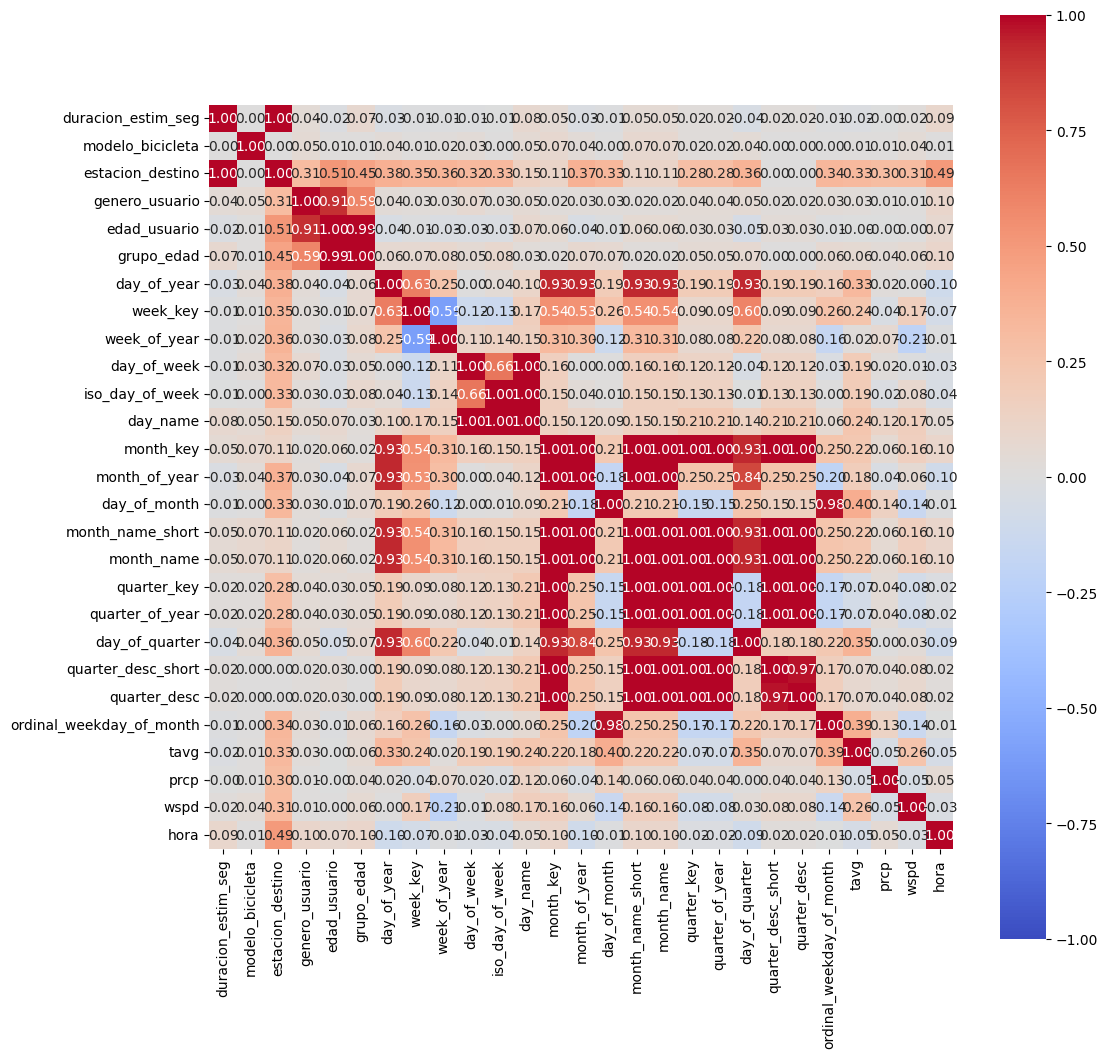

{'corr':                           duracion_estim_seg  modelo_bicicleta  \
 duracion_estim_seg                  1.000000          0.003785   
 modelo_bicicleta                    0.003785          1.000000   
 estacion_destino                    1.000000          0.000000   
 genero_usuario                      0.039695          0.048357   
 edad_usuario                       -0.019021          0.014442   
 grupo_edad                          0.072477          0.010850   
 day_of_year                        -0.031611          0.035063   
 week_key                           -0.014053          0.011370   
 week_of_year                       -0.014844          0.021965   
 day_of_week                        -0.011373          0.034329   
 iso_day_of_week                    -0.006308          0.004294   
 day_name                            0.077551          0.048858   
 month_key                           0.048141          0.072487   
 month_of_year                      -0.027483         

In [162]:
from dython.nominal import associations
import matplotlib.pyplot as plt
# Calcular asociaciones para todas las variables
associations(df, figsize=(12, 12), cmap='coolwarm')


Esta funcion nos permite ver una matriz de correlación tanto para variables numericas como categoricas. Esto nos ayuda a ver que las variables principales de análisis son:
"month_of_year", "day_of_month" , "iso_day_of_week", "estacion_destino", "grupo_edad", "tavg", "prcp", "wspd" y edad usuario.

Debido a la cantidad de falta de datos, eliminamos también la variable de edad usuario, grupo edad.


In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1901 entries, 622 to 3500626
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   duracion_estim_seg        1901 non-null   int64  
 1   modelo_bicicleta          1901 non-null   object 
 2   estacion_destino          1901 non-null   object 
 3   genero_usuario            805 non-null    object 
 4   edad_usuario              805 non-null    Int64  
 5   grupo_edad                805 non-null    object 
 6   day_of_year               1901 non-null   int64  
 7   week_key                  1901 non-null   int64  
 8   week_of_year              1901 non-null   int64  
 9   day_of_week               1901 non-null   int64  
 10  iso_day_of_week           1901 non-null   int64  
 11  day_name                  1901 non-null   object 
 12  month_key                 1901 non-null   object 
 13  month_of_year             1901 non-null   int64  
 14  day_of_m

In [164]:
df = df[["month_of_year", "day_of_month" , "iso_day_of_week", "estacion_destino","hora", "tavg", "prcp", "wspd"]].copy()
df["prcp"] = df["prcp"].fillna(0)
df

,month_of_year,day_of_month,iso_day_of_week,estacion_destino,hora,tavg,prcp,wspd
622,10,18,5,131- HOSPITAL DE CLÍNICAS,17,21.1,0.0,8.9
1721,10,18,5,064 - RIOBAMBA,13,21.1,0.0,8.9
1736,10,18,5,286 - FILOSOFIA Y LETRAS,17,21.1,0.0,8.9
1948,10,18,5,041 - PARQUE PATRICIOS II,12,21.1,0.0,8.9
2536,10,17,4,084 - TEATRO PICADERO,18,26.6,0.5,7.1
...,...,...,...,...,...,...,...,...
3495632,10,25,5,073 - Ruy Díaz de Guzmán,15,22.6,3.3,6.7
3500105,10,28,1,152 - JULIETA LANTERI,8,24.4,0.0,8.2
3500462,10,26,6,179 - CASA SAN,13,16.9,0.0,4.7
3500495,10,26,6,008 - Congreso,19,16.9,0.0,4.7


Ademas de ello, vamos a generar un indice que combine todas las métricas climaticas, para evaluar su desempeño:

<Axes: xlabel='tavg', ylabel='Count'>

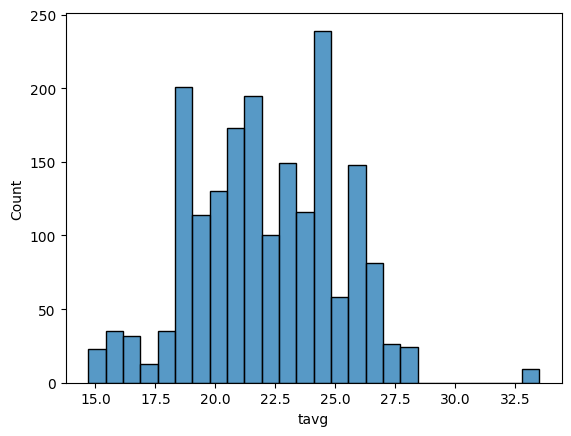

In [165]:
sns.histplot(df, x="tavg")

standart scaler

<Axes: xlabel='wspd', ylabel='Count'>

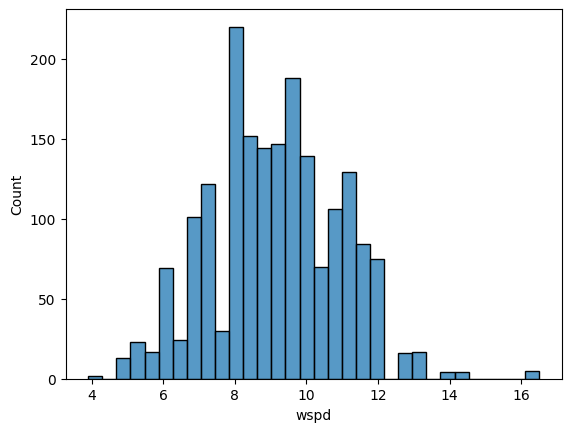

In [166]:
sns.histplot(df, x="wspd")

esta la escalamos con standart scaler

<Axes: xlabel='prcp', ylabel='Count'>

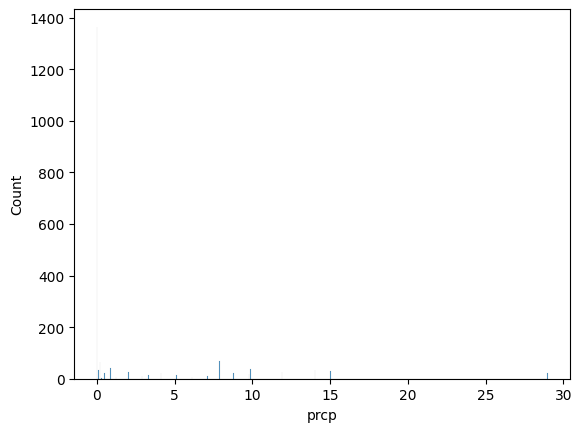

In [167]:
sns.histplot(df, x="prcp")

Esta la escalamos con normalizacion min max

In [168]:
df['norm_temp'] = (df['tavg'] - 10) / (25 - 10)  # 10°C (cold) to 25°C (ideal)
df['norm_precip'] = 1 - (df['prcp'] / 10).clip(0, 1)  # 0mm (ideal) to 10mm+ (bad)
df['norm_wind'] = 1 - (df['wspd'] / 30).clip(0, 1)  # 0km/h (ideal) to 30km/h+ (bad)

df['cycling_score'] = (
    0.5 * df['norm_temp'] +
    0.3 * df['norm_precip'] +
    0.2 * df['norm_wind']
)

Generamos indicador de fin de semana:

In [169]:
df["is_weekend"] = df["iso_day_of_week"].isin([6,7])

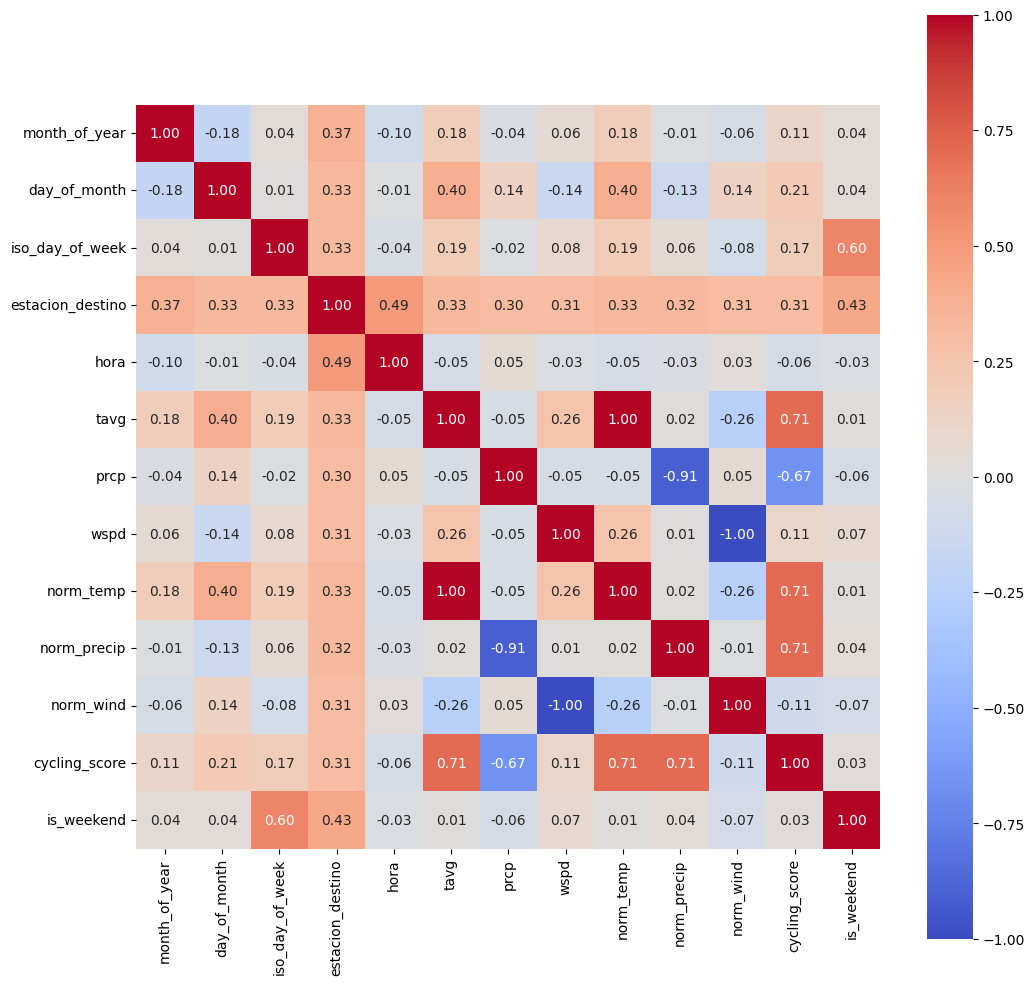

{'corr':                   month_of_year  day_of_month  iso_day_of_week  \
 month_of_year          1.000000     -0.179600         0.035839   
 day_of_month          -0.179600      1.000000         0.014139   
 iso_day_of_week        0.035839      0.014139         1.000000   
 estacion_destino       0.371989      0.331626         0.327688   
 hora                  -0.098807     -0.009005        -0.039440   
 tavg                   0.179088      0.395787         0.189994   
 prcp                  -0.035084      0.142055        -0.018170   
 wspd                   0.056550     -0.142665         0.084024   
 norm_temp              0.179088      0.395787         0.189994   
 norm_precip           -0.014882     -0.128056         0.062138   
 norm_wind             -0.056550      0.142665        -0.084024   
 cycling_score          0.113809      0.208351         0.173159   
 is_weekend             0.041530      0.037508         0.600731   
 
                   estacion_destino      hora      t

In [170]:
associations(df, figsize=(12, 12), cmap='coolwarm')

Con esto, vemos que podemos eliminar algunas de las variables:
- tavg: la eliminamos en base a la temperatura normalizada
- prcp . idem
- wspd: idem

In [171]:
X = df.drop(columns="estacion_destino").copy()
y = df["estacion_destino"].copy()

In [172]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))

# Normalizamos

In [173]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
X_train.columns

Index(['month_of_year', 'day_of_month', 'iso_day_of_week', 'hora', 'tavg',
       'prcp', 'wspd', 'norm_temp', 'norm_precip', 'norm_wind',
       'cycling_score', 'is_weekend'],
      dtype='object')

In [174]:
# Assuming you have these periods for cyclical features
DAY_OF_MONTH_PERIOD = 31
DAY_OF_WEEK_PERIOD = 7
HOUR_PERIOD = 24


def sin_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))
    # Añadimos nombres de columnas manualmente
    transformer.get_feature_names_out = lambda input_features: [f"{col_name}_sin"]
    return transformer

def cos_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))
    transformer.get_feature_names_out = lambda input_features: [f"{col_name}_cos"]
    return transformer

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encode month_of_year
        ('month_onehot', OneHotEncoder(), ['month_of_year']),
        
        # Transformaciones cíclicas (con nombres personalizados)
        ('day_of_month_sin', sin_transformer(31, "day_of_month"), ['day_of_month']),
        ('day_of_month_cos', cos_transformer(31, "day_of_month"), ['day_of_month']),
        
        ('day_of_week_sin', sin_transformer(7, "day_of_week"), ['iso_day_of_week']),
        ('day_of_week_cos', cos_transformer(7, "day_of_week"), ['iso_day_of_week']),
        
        ('hour_sin', sin_transformer(24, "hour"), ['hora']),
        ('hour_cos', cos_transformer(24, "hour"), ['hora']),
        
        # Standard scaling for tavg and wspd
        ('standard_scaler', StandardScaler(), ['tavg', 'wspd']),
        
        # MinMax scaling for prcp
        ('minmax_scaler', MinMaxScaler(), ['prcp'])
    ],
    remainder='drop'  # This will drop any columns not specified
)

# Create the full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])


In [175]:
X_train["month_of_year"].unique()

array([12, 10, 11,  9])

In [176]:
pipeline.fit(X_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('month_onehot',
                                                  OneHotEncoder(),
                                                  ['month_of_year']),
                                                 ('day_of_month_sin',
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x0000026C8FBD7520>),
                                                  ['day_of_month']),
                                                 ('day_of_month_cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x0000026C8FBD75B0...
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x0000026C8FBD77F0>),
                                                  ['iso_day_of_week']),
                                                 ('hour_sin',
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x0000026C8F402710>),
                                                  ['hora']),
                                                 ('hour_cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x0000026C920D77F0>),
                                                  ['hora']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['tavg', 'wspd']),
                                                 ('minmax_scaler',
                                                  MinMaxScaler(),
                                                  ['prcp'])]))])

In [177]:
X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

In [178]:
X_train_transformed

array([[ 0.        ,  0.        ,  0.        , ...,  0.27881418,
        -1.01899347,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.5449538 ,
         0.25879615,  0.48275862],
       [ 0.        ,  1.        ,  0.        , ...,  0.17901182,
        -1.35232989,  0.1137931 ],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.45306978,
         1.64769791,  0.00689655],
       [ 0.        ,  1.        ,  0.        , ...,  1.14376796,
         0.64768864,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., -2.11644242,
        -1.29677382,  0.        ]], shape=(1273, 13))

In [179]:
def get_feature_names(column_transformer):
    # lista de nombres resultantes
    output_features = []
    
    for name, transformer, columns in column_transformer.transformers_:
        if transformer == 'drop':
            continue
        if transformer == 'passthrough':
            # columnas que pasan sin transformar
            if isinstance(columns, slice):
                # si es slice, obtén nombres desde input_features
                feature_names = column_transformer.feature_names_in_[columns]
            elif isinstance(columns, list):
                feature_names = columns
            else:
                feature_names = [columns]
            output_features.extend(feature_names)
            continue

        # Si el transformer tiene get_feature_names_out(), úsalo
        if hasattr(transformer, 'get_feature_names_out'):
            if isinstance(columns, list):
                names = transformer.get_feature_names_out(columns)
            else:
                names = transformer.get_feature_names_out()
            output_features.extend(names)
        else:
            # Para transformers que no tienen get_feature_names_out, poner nombres manuales
            # Por ejemplo, si sabes que genera 1 columna:
            if hasattr(transformer, 'n_features_out_'):
                n = transformer.n_features_out_
            else:
                # valor por defecto (1)
                n = 1
            # Crear nombres genéricos
            names = [f"{name}__{i}" for i in range(n)]
            output_features.extend(names)

    return output_features

# Luego:
feature_names = get_feature_names(pipeline.named_steps['preprocessor'])
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)


In [180]:
X_train_transformed_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1273 entries, 0 to 1272
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   month_of_year_9      1273 non-null   float64
 1   month_of_year_10     1273 non-null   float64
 2   month_of_year_11     1273 non-null   float64
 3   month_of_year_12     1273 non-null   float64
 4   day_of_month_sin__0  1273 non-null   float64
 5   day_of_month_cos__0  1273 non-null   float64
 6   day_of_week_sin__0   1273 non-null   float64
 7   day_of_week_cos__0   1273 non-null   float64
 8   hour_sin__0          1273 non-null   float64
 9   hour_cos__0          1273 non-null   float64
 10  tavg                 1273 non-null   float64
 11  wspd                 1273 non-null   float64
 12  prcp                 1273 non-null   float64
dtypes: float64(13)
memory usage: 129.4 KB


In [184]:
y_train.unique()

array(['373 - Jorgelina De Simone', '008 - Congreso', '091 - Pasco',
       '169 - FACULTAD DE PSICOLOGIA', '147 - Constitución', '013 - ONCE',
       '082 - HOSPITAL ITALIANO', '107 - HOSPITAL GARRAHAN',
       '172 - BRASIL', '150 - RODRIGO BUENO', '046 - Chile',
       '027 - Montevideo', '146 - Hospital Francés', '086 - SAAVEDRA',
       '331 - CALIFORNIA', '117 - HUMBERTO 1°', '084 - TEATRO PICADERO',
       '183 - VIRREY CEVALLOS', '080 - VALLE', '006 - Parque Lezama',
       '153 - JUAN MANUEL DE BLANES', '038 - Plaza Libertad',
       '061 - Ministerio de Economia', '076 - Ayacucho',
       '272 - Plaza Bruno Giordano', '041 - PARQUE PATRICIOS II',
       '164 - FACULTAD DE INGENIERIA', '152 - JULIETA LANTERI',
       '073 - Ruy Díaz de Guzmán', '007 - OBELISCO',
       '199 - ESTADOS UNIDOS Y BOEDO', '184 - Pedro Echague',
       '273 - Plazoleta Colombia', '069 - Ecuador',
       '340 - PLAZA NUEVA POMPEYA', '144 - PUEYRREDÓN',
       '120 - HOSPITAL RAMOS MEJIA', '063 - Reco

C:\Users\Juan\AppData\Local\Temp\ipykernel_20892\2234515672.py:13: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=pca_df, x='PC1', y='PC2', palette='viridis', s=60, alpha=0.7)
C:\Users\Juan\AppData\Local\Temp\ipykernel_20892\2234515672.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Etiqueta')


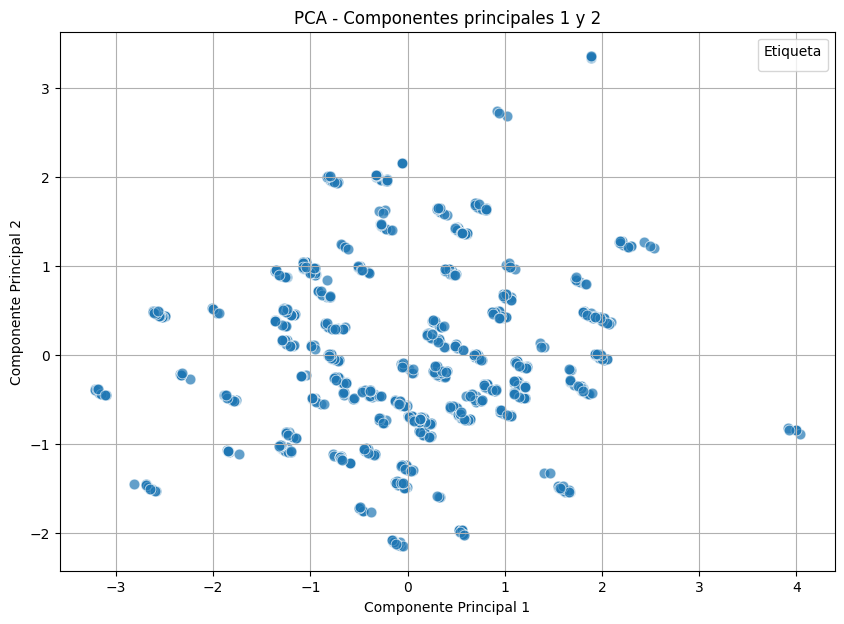

In [197]:
from sklearn.decomposition import PCA
features = X_train_transformed_df.columns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_transformed_df)

labels = y_train.copy()

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['label'] = labels

plt.figure(figsize=(10,7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', palette='viridis', s=60, alpha=0.7)
plt.title('PCA - Componentes principales 1 y 2')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Etiqueta')
plt.grid(True)
plt.show()

In [198]:
print(X_pca[0].min())
print(X_pca[0].max())

print(X_pca[1].min())
print(X_pca[1].max())

pca.explained_variance_ratio_

-1.428622081115421
-0.08084500423968141
0.009446707966578927
0.6825520121371026


array([0.23787088, 0.16149249])